# Benchmark K-Means
This notebook compares the original Lab 3 K-Means implementation with the AI-generated Lab 4 implementation.

**Instructions:**
1. Make sure to have `lab3.py` and `lab4.py` available in the same environment.
2. Upload `Lab Session Data.xlsx` to the Colab session.

In [11]:
# If running in Colab, download the required scripts
!wget -q https://raw.githubusercontent.com/pratyushadk/ML-Lab/main/Lab_3/code/lab3.py
!wget -q https://raw.githubusercontent.com/pratyushadk/ML-Lab/main/Lab_4/code/lab4.py

import sys
import time
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import io
from contextlib import redirect_stdout

# Suppress lab3.py's output on import
f = io.StringIO()
with redirect_stdout(f):
    from lab3 import kmeans as kmeans_v1, minkowski_distance as minkowski_v1
from lab4 import kmeans as kmeans_v2, label_encode, one_hot_encode

In [12]:
def load_and_preprocess_data():
    # Assumes 'Lab Session Data.xlsx' is uploaded directly to the Colab environment
    excel_path = 'Lab Session Data.xlsx'

    df_raw = pd.read_excel(excel_path, sheet_name='marketing_campaign')

    df_encoded = df_raw.copy()
    if 'Dt_Customer' in df_encoded.columns:
        df_encoded = df_encoded.drop(columns=['Dt_Customer'])
    df_encoded = df_encoded.dropna(subset=['Income']).reset_index(drop=True)

    # We just need some normalized numerical data for benchmarking
    km_feats = ['Income', 'MntWines']
    raw_km = df_encoded[km_feats].values
    km_data_norm = (raw_km - raw_km.min(axis=0)) / (raw_km.max(axis=0) - raw_km.min(axis=0) + 1e-9)
    return km_data_norm

In [13]:
print("Loading data for benchmark...")
try:
    data = load_and_preprocess_data()
except Exception as e:
    print(f"Error loading data: {e}")
    print("\nMake sure you have uploaded 'Lab Session Data.xlsx' to the Colab environment.")
    raise e

k = 3
iterations = 50

print("\n--- Running Version 1 (Lab 3: User Written) ---")
start_v1 = time.perf_counter()
labels_v1, centroids_v1, inertia_v1, _ = kmeans_v1(data, k=k, max_iterations=iterations, random_seed=42)
end_v1 = time.perf_counter()
time_v1 = end_v1 - start_v1
print(f"Version 1 Time: {time_v1:.4f} seconds")
print(f"Version 1 Inertia: {inertia_v1:.4f}")

print("\n--- Running Version 2 (Lab 4: AI Generated) ---")
start_v2 = time.perf_counter()
labels_v2, centroids_v2, inertia_v2, _ = kmeans_v2(data, k=k, max_iterations=iterations, random_seed=42)
end_v2 = time.perf_counter()
time_v2 = end_v2 - start_v2
print(f"Version 2 Time: {time_v2:.4f} seconds")
print(f"Version 2 Inertia: {inertia_v2:.4f}")

Loading data for benchmark...

--- Running Version 1 (Lab 3: User Written) ---
Version 1 Time: 1.7973 seconds
Version 1 Inertia: 14.7458

--- Running Version 2 (Lab 4: AI Generated) ---
Version 2 Time: 1.2984 seconds
Version 2 Inertia: 14.7458



--- Performance Comparison Summary ---
Faster Algorithm: Version 2 (AI Generated) (by 1.38x)


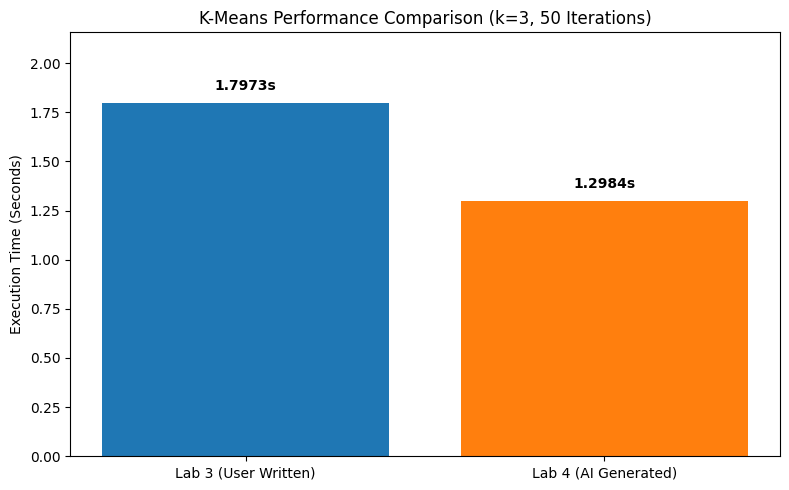

In [14]:
print("\n--- Performance Comparison Summary ---")
if time_v1 < time_v2:
    faster = "Version 1 (User Written)"
    speedup = time_v2 / time_v1
else:
    faster = "Version 2 (AI Generated)"
    speedup = time_v1 / time_v2
print(f"Faster Algorithm: {faster} (by {speedup:.2f}x)")

versions = ['Lab 3 (User Written)', 'Lab 4 (AI Generated)']
times = [time_v1, time_v2]

plt.figure(figsize=(8, 5))
bars = plt.bar(versions, times, color=['#1f77b4', '#ff7f0e'])
plt.ylabel('Execution Time (Seconds)')
plt.title('K-Means Performance Comparison (k=3, 50 Iterations)')
plt.ylim(0, max(times) * 1.2)

for bar in bars:
    yval = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, yval + 0.05, f"{yval:.4f}s", ha='center', va='bottom', fontweight='bold')

plt.tight_layout()
plt.show()